# Laboratorium 6: Od wyników do modelu gotowego do użycia

Łączymy preprocessing, modelowanie, interpretację i proste kontrole jakości.

## Cele
- zbudować pipeline z `ColumnTransformer`,
- porównać model bazowy i model z preprocessingiem,
- obejrzeć znaczenie cech,
- zrobić prosty check na przesunięcie danych i jakość predykcji,
- przygotować krótki szablon raportu.

## Importy

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from aif360.metrics import ClassificationMetric
from aif360.datasets import BinaryLabelDataset
from sklearn.compose import ColumnTransformer
from sklearn.datasets import load_breast_cancer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)

pip install 'aif360[AdversarialDebiasing]'
pip install 'aif360[AdversarialDebiasing]'
pip install 'aif360[Reductions]'
pip install 'aif360[Reductions]'
pip install 'aif360[inFairness]'
pip install 'aif360[Reductions]'


## 1. Dane

In [2]:
data = load_breast_cancer(as_frame=True)
X = data.data.copy()
y = data.target.copy()
X.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

## 2. Pipeline

In [24]:
numeric_features = X.columns.tolist()
preprocess = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]), numeric_features),
])

model = Pipeline([
    ("preprocess", preprocess),
    ("clf", LogisticRegression(max_iter=2)),  # Specjalnie użyto małej wartości "max_iter" :)
])

model.fit(X_train, y_train)

pred = model.predict(X_test)
proba = model.predict_proba(X_test)[:, 1]
print("accuracy:", accuracy_score(y_test, pred))
print(classification_report(y_test, pred, target_names=data.target_names))

accuracy: 0.951048951048951
              precision    recall  f1-score   support

   malignant       0.94      0.92      0.93        53
      benign       0.96      0.97      0.96        90

    accuracy                           0.95       143
   macro avg       0.95      0.95      0.95       143
weighted avg       0.95      0.95      0.95       143



/Users/marcinbodych/Workspace/2026-pwr/statystyczna_analiza_danych/PWR-SAD-LABS/Lab6/.venv/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 2 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


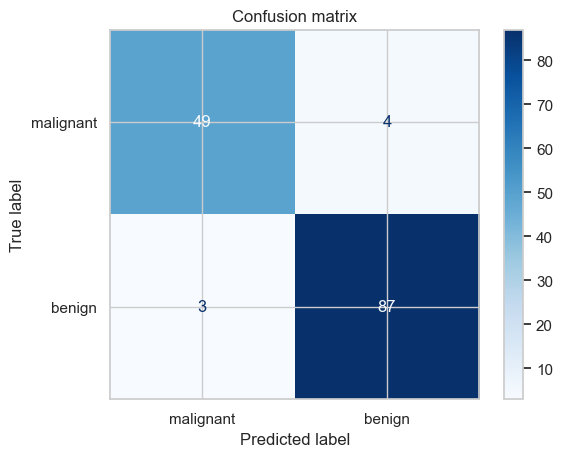

In [11]:
cm = confusion_matrix(y_test, pred)
ConfusionMatrixDisplay(cm, display_labels=data.target_names).plot(cmap="Blues")
plt.title("Confusion matrix")
plt.show()

## 3. Interpretowalność przez współczynniki

In [12]:
coefs = pd.Series(model.named_steps["clf"].coef_[0], index=numeric_features).sort_values(key=np.abs, ascending=False)
coefs.head(10)

worst radius           -0.306722
worst perimeter        -0.305488
worst concave points   -0.293915
worst area             -0.290660
mean perimeter         -0.290536
mean radius            -0.288339
mean concave points    -0.287636
mean area              -0.280596
mean concavity         -0.232629
worst concavity        -0.226786
dtype: float64

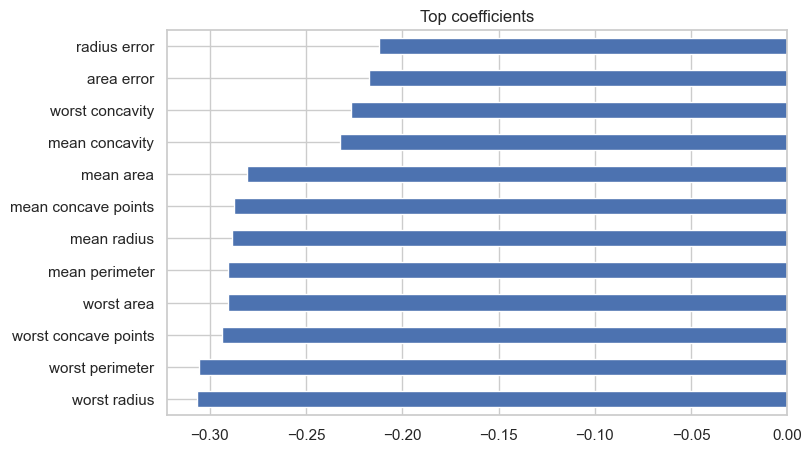

In [13]:
coefs.head(12).sort_values().plot(kind="barh", figsize=(8, 5))
plt.title("Top coefficients")
plt.show()

## 4. Fairness z IBM AI Fairness 360
Wprowadzenie: https://fairlearn.org/main/user_guide/fairness_in_machine_learning.html

Przygotujemy metryki różnic w traktowaniu dwóch grup chronionych opartych na `mean symmetry`.
Użyjemy `BinaryLabelDataset` i `ClassificationMetric`, żeby porównać wynik modelu względem tych grup.


In [14]:
df_fair = X_test.copy()
df_fair["target"] = y_test
df_fair["group"] = (df_fair["mean symmetry"] >= df_fair["mean symmetry"].median()).astype(int)
df_fair["prediction"] = pred
df_fair["proba"] = proba
base_dataset = BinaryLabelDataset(df=df_fair, label_names=["target"], protected_attribute_names=["group"], favorable_label=1, unfavorable_label=0)
pred_df = df_fair.copy()
pred_df["target"] = df_fair["prediction"]
pred_dataset = BinaryLabelDataset(df=pred_df, label_names=["target"], protected_attribute_names=["group"], favorable_label=1, unfavorable_label=0)
metric = ClassificationMetric(base_dataset, pred_dataset, unprivileged_groups=[{"group": 0}], privileged_groups=[{"group": 1}])
fair_metrics = {
    "demographic_parity_diff": metric.mean_difference(),
    "average_odds_diff": metric.average_odds_difference(),
    "statistical_parity_diff": metric.statistical_parity_difference(),
}
fair_metrics


{'demographic_parity_diff': np.float64(0.2466744913928013),
 'average_odds_diff': np.float64(0.09831002331002328),
 'statistical_parity_diff': np.float64(0.2466744913928013)}

Wartości powyżej pokazują, jak bardzo model różnicuje wyniki dla grup: `demographic_parity_diff` i `average_odds_diff` bliskie 0 oznaczają, że faworyzowanie obu grup jest zbliżone.
W praktycznym raporcie odnotowujemy, która grupa jest uprzywilejowana i czy różnice wymagają uwagi (np. dodatkowego przetworzenia danych lub wyniku).


demographic_parity_diff - https://fairlearn.org/main/api_reference/generated/fairlearn.metrics.demographic_parity_difference.html
average_odds_diff - https://aif360.readthedocs.io/en/latest/modules/generated/aif360.sklearn.metrics.average_odds_difference.html
statistical_parity_diff - https://dataplatform.cloud.ibm.com/docs/content/wsj/model/wos-stat-parity-diff.html

### Kroki monitoringu fairness z IBM AI Fairness 360
1. `BinaryLabelDataset` definiuje dane + atrybut chroniony (`protected_attribute_names`).
2. Trenujemy model, tworzymy predykcje i generujemy dataset z predykcjami i `favorable_label`.
3. `ClassificationMetric` porównuje zestawy (baseline vs current) i liczy `demographic_parity_diff`, `average_odds_difference`, `statistical_parity_difference` itd.
4. Dodatkowo mamy możliwość aplikowania strategii (https://github.com/Trusted-AI/AIF360#supported-bias-mitigation-algorithms), a wyniki monitorujemy na wykresie histogramów + tabeli metryk.
5. W reportach zapisujemy wartości metryk i decyzje: jeśli różnice przekroczą próg, notujemy akcję (alert/ retraining / preprocess).


## 5. Prosty check driftu i jakości
Porównujemy rozkład cechy w train i test przez test KS.

In [17]:
feature = "mean radius"
ks = stats.ks_2samp(X_train[feature], X_test[feature])
print(ks)

KstestResult(statistic=np.float64(0.04970616238221872), pvalue=np.float64(0.939354558461395), statistic_location=np.float64(12.87), statistic_sign=np.int8(1))


In [18]:
report = pd.DataFrame({
    "metric": ["accuracy", "ks_stat", "ks_pvalue"],
    "value": [accuracy_score(y_test, pred), ks.statistic, ks.pvalue],
})
report

,metric,value
0,accuracy,0.951049
1,ks_stat,0.049706
2,ks_pvalue,0.939355


## 6. Symulowany pipeline monitoringu i driftu
Do danych testowych dodajemy przesunięcie w `mean radius` i `mean symmetry`,
liczymy nowe predykcje, metryki KS, co ilustruje w jaki sposób można reagować na spadki jakości.


In [22]:
shifts = pd.DataFrame({
    "mean radius mult": [1.0, 1.02, 1.04, 1.06],
    "mean symmetry shift": [0.0, 0.01, 0.02, 0.03],
})
results = []
for i, row in shifts.iterrows():
    X_shift = X_test.copy()
    X_shift["mean radius"] *= row["mean radius mult"]
    X_shift["mean symmetry"] += row["mean symmetry shift"]
    pred_shift = model.predict(X_shift)
    ks_shift = stats.ks_2samp(X_train["mean radius"], X_shift["mean radius"])
    acc = accuracy_score(y_test, pred_shift)
    results.append({
        "radius_scale": row["mean radius mult"],
        "symmetry_shift": row["mean symmetry shift"],
        "accuracy": acc,
        "ks_stat": ks_shift.statistic,
        "ks_pvalue": ks_shift.pvalue,
    })
results_df = pd.DataFrame(results)
results_df


,radius_scale,symmetry_shift,accuracy,ks_stat,ks_pvalue
0,1.00,0.00,0.951049,0.049706,0.939355
1,1.02,0.01,0.951049,0.090400,0.321485
2,1.04,0.02,0.930070,0.121097,0.078382
3,1.06,0.03,0.930070,0.162382,0.006092


Ostatni wiersz sugeruje zauważalny drift (pvalue < 0.05)

## 7. Szablon krótkiego raportu
- cel modelu
- dane i preprocessing
- wynik modelu
- interpretacja
- uwagi o jakości danych i ograniczeniach

### Uwaga, dla danych typu szeregi czasowe, np najnowsze punkty danych można użyć do badania zjawiska driftu.
#### Dla danych bez szeregów czasowych, można użyć podejścia z wydzieleniem podgrupy